<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_2_4_kNN_%D0%9A%D1%80%D0%BE%D1%81%D0%B2%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D1%96_%D1%82%D1%8E%D0%BD%D0%B8%D0%BD%D0%B3_%D0%B3%D1%96%D0%BF%D0%B5%D1%80%D0%BF%D0%B0%D1%80%D0%B0%D0%BC%D0%B5%D1%82%D1%80%D1%96%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [1]:
import pandas as pd
import numpy as np
import time

In [2]:
%load_ext autoreload
%autoreload 2

from process_bank_churn import (preprocess_data, preprocess_new_data)

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [5]:
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(df)

1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

In [7]:
# Ініціалізуємо kNN-класифікатор (default: n_neighbors=5)
knn = KNeighborsClassifier()

In [8]:
# Навчаємо на тренувальних даних
knn.fit(X_train, train_targets)

KNeighborsClassifier()

In [9]:
# Прогнозуємо ймовірності для позитивного класу (Exited == 1)
train_probs = knn.predict_proba(X_train)[:, 1]
val_probs = knn.predict_proba(X_val)[:, 1]

In [10]:
# Обчислюємо AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")

Train AUROC: 0.9559
Validation AUROC: 0.8525


**Спостереження**

- Train AUROC ≈ 0.96 - модель дуже добре навчається на тренувальних даних.

- Validation AUROC ≈ 0.85 - також достатньо хороша якість на валідаційному наборі.

- Різниця між train і val AUROC ≈ 0.10 (тобто 10%) - це помірна різниця, яка свідчить про деяке перенавчання (high variance).

Отже, модель добре "запам’ятала" тренувальні приклади, але трохи гірше узагальнює на нових, невідомих даних (можливо, занадто маленьке n_neighbors=5).

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [11]:
# Визначаємо параметри для перебору
param_grid = {'n_neighbors': list(range(1, 31))}

In [12]:
# Створюємо GridSearchCV з 5-фолдовою крос-валідацією і метрикою AUROC
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [13]:
# Навчаємо GridSearch на тренувальному наборі
grid_search.fit(X_train, train_targets)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='roc_auc')

In [14]:
# Отримуємо найкращий параметр
best_k = grid_search.best_params_['n_neighbors']
print(f"Найкраще значення n_neighbors: {best_k}")

Найкраще значення n_neighbors: 19


In [15]:
# Оцінюємо найкращу модель на валідації
best_knn = grid_search.best_estimator_
val_probs = best_knn.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(val_targets, val_probs)
print(f"Validation AUROC для найкращого k: {val_auc:.4f}")

Validation AUROC для найкращого k: 0.8908


**Спостереження**

Підбір гіперпараметра n_neighbors значно покращив якість моделі. Validation AUROC для найкращого k = 19: 0.8908 - це суттєве покращення порівняно з попереднім значенням (≈ 0.8525 при k=5 за замовченням). Модель краще узагальнює,а отже, high variance стало меншим.

Хоча, при використанні дерева прийняття рішень я отримала дещо краще значення AUROC на валідаційних даних - 0.8911.

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
# Визначення сітки параметрів
param_grid = {
    'max_depth': list(range(1, 21, 2)),        # [1, 3, 5, ..., 19]
    'max_leaf_nodes': list(range(2, 11))       # [2, 3, ..., 10]
}

In [18]:
# Ініціалізація моделі з фіксацією random_state
dt = DecisionTreeClassifier(random_state=42)

In [19]:
# Ініціалізація GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=0
)

In [20]:
# Вимірювання часу
start_time = time.time()
grid_search_dt.fit(X_train, train_targets)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Час пошуку: {elapsed_time:.2f} секунд")

Час пошуку: 5.97 секунд


In [21]:
# Найкращі параметри
best_params = grid_search_dt.best_params_
print("Найкращі параметри:", best_params)

Найкращі параметри: {'max_depth': 5, 'max_leaf_nodes': 10}


In [22]:
# Збереження найкращої моделі
dt_best = grid_search_dt.best_estimator_

In [23]:
# Прогнози на train і val
train_probs_dt = dt_best.predict_proba(X_train)[:, 1]
val_probs_dt = dt_best.predict_proba(X_val)[:, 1]

In [24]:
# Обчислення AUROC
train_auc_dt = roc_auc_score(train_targets, train_probs_dt)
val_auc_dt = roc_auc_score(val_targets, val_probs_dt)

print(f"Train AUROC: {train_auc_dt:.4f}")
print(f"Validation AUROC: {val_auc_dt:.4f}")


Train AUROC: 0.9015
Validation AUROC: 0.9002


**Спостереження**

- Train AUROC: 0.9015 - для Decision Tree модель досить добре навчається на тренувальних даних, хоча й гірше, ніж kNN. Це свідчить про дещо меншу гнучкість дерева порівняно з kNN.

- Validation AUROC: 0.9002 - це дуже хороше значення на валідаційному наборі, і що важливо: AUROC майже однаковий для тренувальної та валідаційної вибірки, що означає відсутність суттєвого overfitting (high variance).

Порівняння з kNN:

Для Decision Tree AUROC на валідації (0.9002) краще, ніж для kNN (0.8908), тобто модель дерева дає кращі результати в даному випадку.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [25]:
from sklearn.model_selection import RandomizedSearchCV

In [26]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [27]:
# Ініціалізація RandomizedSearchCV
random_search_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=params_dt,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [28]:
# Вимірювання часу пошуку
start_time = time.time()
random_search_dt.fit(X_train, train_targets)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Час пошуку: {elapsed_time:.2f} секунд")

Час пошуку: 1.63 секунд


In [29]:
# Найкращі параметри
best_params_random_search = random_search_dt.best_params_
print("Найкращі параметри (RandomizedSearchCV):", best_params_random_search)

Найкращі параметри (RandomizedSearchCV): {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_leaf_nodes': np.int64(14), 'max_features': None, 'max_depth': np.int64(16), 'criterion': 'entropy'}


In [30]:
# Збереження найкращої моделі
dt_random_search_best = random_search_dt.best_estimator_

In [31]:
# Прогнози на train і val
train_probs_dt_random = dt_random_search_best.predict_proba(X_train)[:, 1]
val_probs_dt_random = dt_random_search_best.predict_proba(X_val)[:, 1]

In [32]:
# Обчислення AUROC
train_auc_dt_random = roc_auc_score(train_targets, train_probs_dt_random)
val_auc_dt_random = roc_auc_score(val_targets, val_probs_dt_random)

print(f"Train AUROC (RandomizedSearchCV): {train_auc_dt_random:.4f}")
print(f"Validation AUROC (RandomizedSearchCV): {val_auc_dt_random:.4f}")

Train AUROC (RandomizedSearchCV): 0.9169
Validation AUROC (RandomizedSearchCV): 0.9166


**Спостереження**

- GridSearchCV - обмежує глибину дерева і кількість листків для запобігання перенавчанню. Це веде до менш складної, більш узагальненої моделі, яка буде добре працювати на нових даних, але може не використовувати весь потенціал дерева.

- RandomizedSearchCV - вибрав більш складні параметри, що дозволяють дереву бути глибшим та мати більше листків. Також використовуються більш складні критерії для поділу і вищі значення для мінімальних вимог до кількості зразків у вузлах. При цьому ми ще маємо перевагу і по часу пошуку 4.67 секунд проти 6.81 секунд GridSearchCV.

- Train AUROC для RandomizedSearchCV 0.9169 - це покращення порівняно з GridSearchCV (0.9015), що свідчить про кращі результати на тренувальних даних.

- Validation AUROC для RandomizedSearchCV 0.9166 - це суттєве покращення порівняно з GridSearchCV (0.9002) на валідаційних даних.

RandomizedSearchCV у нашому випадку знайшов оптимальні конфігурації, які не потрапили в повний перебір у GridSearchCV, надаючи кращі результати для тестових і валідаційних даних.



5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [33]:
#Завантажуємо тестові дані
test_data = pd.read_csv('test.csv')

In [34]:
X_test_processed = preprocess_new_data(test_data, input_cols, scaler, encoder)

In [35]:
#Передбачення
predictions = dt_random_search_best.predict_proba(X_test_processed)[:, 1]

In [36]:
#Зчитати шаблон для сабміту
submission_df = pd.read_csv("sample_submission.csv")

In [37]:
#Заповнити колонку Exited у шаблоні
submission_df["Exited"] = predictions

In [38]:
submission_df.to_csv("submission.csv", index=False)

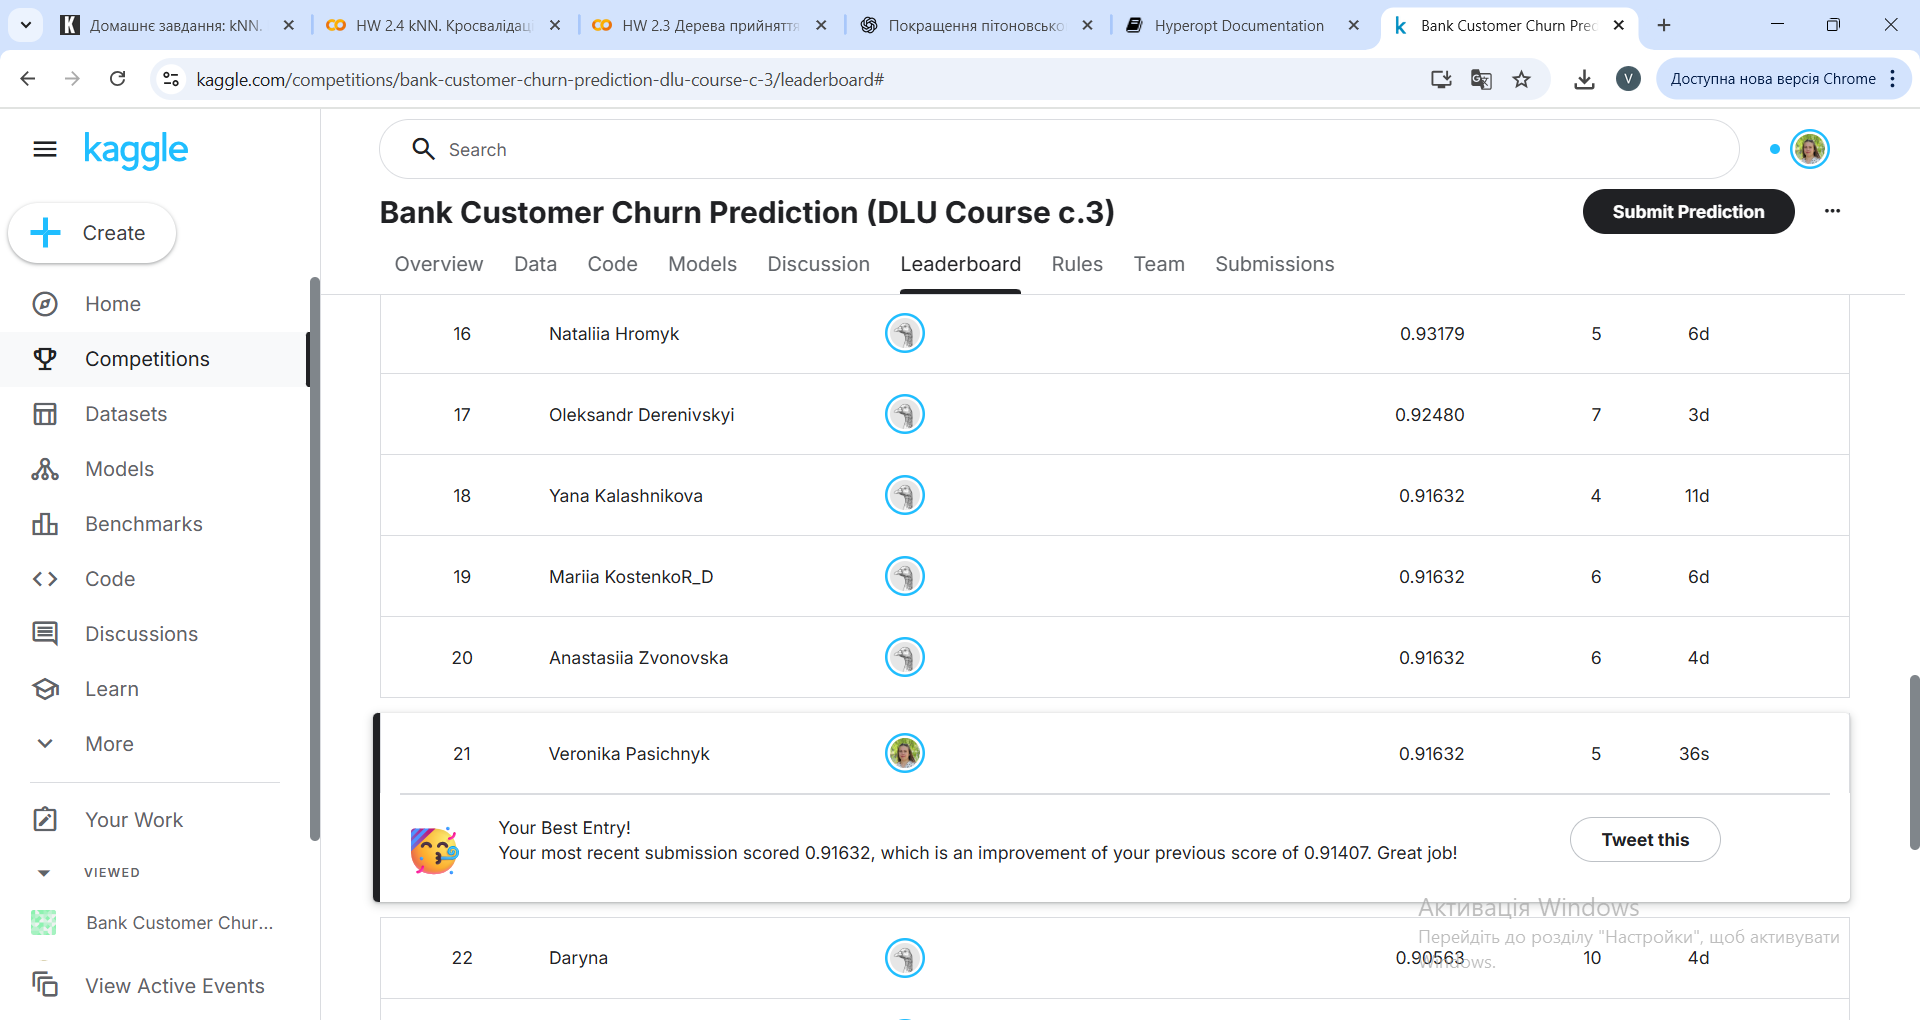